### This notebook only draw the figure with the experimental results
- In the repo., we save the result (csv, pkl) files and re-draw them. 
### 1. To get the original results, run 'mod_ad_test.py' to get the results
### 2. NormA code is not included in this repo. Ask to the author of NormA to get the code for testing 
- For SAND, you can use the below repository (TSB-UAD)
- (see. https://github.com/thedatumorg/TSB-UAD.git)
### 3. DAMP is run by original source code, on MATLAB (which is much faster than python code.)
- (see. https://sites.google.com/view/discord-aware-matrix-profile/documentation)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from util.TSB_AD.metrics import metricor
from util.TSB_AD.slidingWindows import find_length #,plotFig, printResult
from sklearn.preprocessing import MinMaxScaler
import os
import sys
from sklearn import metrics

from tqdm.notebook import tqdm
import math
import arff
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

In [7]:
def running_mean(x,N):
	return (np.cumsum(np.insert(x,0,0))[N:] - np.cumsum(np.insert(x,0,0))[:-N])/N

def read_arff(filename):
    """
    Find ndarray corresponding to data and labels from arff data
    """
    arff_content = arff.load(f.replace(',\n', '\n') for f in open(filename, 'r'))
    arff_data = arff_content['data']
    data = np.array([i[:1] for i in arff_data])
    anomaly_labels = np.array([i[-1] for i in arff_data])
    anomaly_labels = anomaly_labels.reshape((len(anomaly_labels),1))
    return data.astype(float), anomaly_labels.astype(float)

peak_adj_columns = ['AUC', 'Precision', 'Recall', 'F1', 'TH', 'RPrecision', 'RRecall', 'RF1', 'PaK', 'F1_adj', 'Precision_adj', 'Recall_adj', 'roc_auc_adj']

###################################################################
## The source of 'adjust_predict' function is 'TranAD' github repo.
## https://github.com/imperial-qore/TranAD.git
# 
def adjust_predicts(score, label,
                    threshold=None,
                    pred=None,
                    calc_latency=False):
    """
    Calculate adjusted predict labels using given `score`, `threshold` (or given `pred`) and `label`.
    Args:
        score (np.ndarray): The anomaly score
        label (np.ndarray): The ground-truth label
        threshold (float): The threshold of anomaly score.
            A point is labeled as "anomaly" if its score is lower than the threshold.
        pred (np.ndarray or None): if not None, adjust `pred` and ignore `score` and `threshold`,
        calc_latency (bool):
    Returns:
        np.ndarray: predict labels
    """
    if len(score) != len(label):
        raise ValueError("score and label must have the same length")
    score = np.asarray(score)
    label = np.asarray(label)
    latency = 0
    # print(type(score), score.dtype, threshold)
    if pred is None:
        predict = score > threshold
    else:
        predict = pred
    actual = label > 0.1
    anomaly_state = False
    anomaly_count = 0
    for i in range(len(score)):
        if actual[i] and predict[i] and not anomaly_state:
                anomaly_state = True
                anomaly_count += 1
                for j in range(i, 0, -1):
                    if not actual[j]:
                        break
                    else:
                        if not predict[j]:
                            predict[j] = True
                            latency += 1
        elif not actual[i]:
            anomaly_state = False
        if anomaly_state:
            predict[i] = True
    if calc_latency:
        return predict, latency / (anomaly_count + 1e-4)
    else:
        return predict
    
###################################################################
## The source of 'calc_point2point' function is 'TranAD' github repo.
## https://github.com/imperial-qore/TranAD.git
# 
def calc_point2point(predict, actual):
    """
    calculate f1 score by predict and actual.
    Args:
        predict (np.ndarray): the predict label
        actual (np.ndarray): np.ndarray
    """
    TP = np.sum(predict * actual)
    TN = np.sum((1 - predict) * (1 - actual))
    FP = np.sum(predict * (1 - actual))
    FN = np.sum((1 - predict) * actual)
    precision = TP / (TP + FP + 0.00001)
    recall = TP / (TP + FN + 0.00001)
    f1 = 2 * precision * recall / (precision + recall + 0.00001)
    try:
        roc_auc = metrics.roc_auc_score(actual, predict)
    except:
        roc_auc = 0
    return f1, precision, recall, TP, TN, FP, FN, roc_auc


In [8]:
def peakf1_acc(label, score, plot_AUC=False, alpha=0.2):
    grader = metricor()
    result = pd.DataFrame(columns=peak_adj_columns)
    if np.sum(label) != 0:
        auc = metrics.roc_auc_score(label, score)

        # plor ROC curve
        fpr, tpr, _ = metrics.roc_curve(label, score)
        pr, re, thresholds = metrics.precision_recall_curve(label, score)
        # print(f'LEN: {len(thresholds)}')
        if plot_AUC:
            dp = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc)
            dp.plot()
        
        peak_f1, peak_ind = np.nanmax(2*(pr*re)/(pr+re)), np.nanargmax(2*(pr*re)/(pr+re))
        # print(peak_f1, peak_ind)
        peak_ths = thresholds[peak_ind] 
        # print(peak_ths)

        #range anomaly 
        preds = score > peak_ths
        Rrecall, ExistenceReward, OverlapReward = grader.range_recall_new(label, preds, alpha)
        Rprecision = grader.range_recall_new(preds, label, 0)[0]

        if Rprecision + Rrecall==0:
            Rf=0
        else:
            Rf = 2 * Rrecall * Rprecision / (Rprecision + Rrecall)

        # top-k
        k = int(np.sum(label))
        threshold = np.percentile(score, 100 * (1-k/len(label)))

        p_at_k = np.where(score > threshold)[0]
        TP_at_k = sum(label[p_at_k])
        precision_at_k = TP_at_k/k

        ## Adjustment csae
        pred_adj = adjust_predicts(score, label,
                threshold=peak_ths,
                pred=None,
                calc_latency=False)
        
        f1_adj, pr_adj, re_adj, _, _, _, _, auc_adj = calc_point2point(pred_adj, label)

        result.loc[0] = [auc, pr[peak_ind], re[peak_ind], peak_f1, peak_ths, Rprecision, Rrecall, Rf, precision_at_k, f1_adj, pr_adj, re_adj, auc_adj]
        return result
    
def result_f1_acc(methods, scores, label, ths = None):
    result_org = pd.DataFrame(columns=['method'] + peak_adj_columns)
    j = 0
    for i, method in enumerate(methods):
        # r_tmp = get_acc(label.reshape(-1)[:len(scores[i])], np.array(scores[i]), slidingWindow, ths)
        r_tmp = peakf1_acc(label.reshape(-1)[:len(scores[i])], np.array(scores[i]), plot_AUC=False)
        if r_tmp is not None:
            result_org.loc[j] = [method] + list(r_tmp.loc[0])
        else:
            result_org.loc[j] = [method] + [0]*len(peak_adj_columns)
        j+=1

    # display(result_org)
    return result_org

### Figs

In [ ]:
### The results of DAMP in this pkl was not used in our experiments. 
### We re-run the MATLAB code for fair comparison. 
methods = ['NormA', 'SAND', 'DAMP']
dir = os.getcwd() + '/data/test_mod/org'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.arff')]
print(filenames)
org_labels = []
result_org = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)

with open(f'{dir}/result_org(score).pkl', 'rb') as f:
    org_scores = pickle.load(f)

for i, file in enumerate(filenames):
    data, label = read_arff(f'{dir}/{file}')
    org_labels.append(label)
    
    # for j, method in enumerate(methods):
    r_tmp = result_f1_acc(methods, org_scores[0], label.flatten())
    r_tmp['file'] = file
    result_org = pd.concat([result_org, r_tmp])

result_org
    

['MBA_ECG803_data.arff']


,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,MBA_ECG803_data.arff,NormA,0.996848,0.894509,0.880635,0.887518,0.778390,0.895315,0.901714,0.898503,0.886893,0.943801,0.904742,0.986395,0.990588
1,MBA_ECG803_data.arff,SAND,0.979336,0.547410,0.812698,0.654182,0.465498,0.577369,0.828317,0.680443,0.620771,0.695374,0.570127,0.891156,0.928694


### n_drift

In [11]:
dir = os.getcwd() + '/data/test_mod/n_drift'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.arff')]
print(filenames)
n_d_labels = []
result_n_drift = pd.DataFrame(columns=['file'] + peak_adj_columns)

with open(f'{dir}/result_n_drift(score)2.pkl', 'rb') as f:
    n_d_scores = pickle.load(f)

for i, file in enumerate(filenames):
    data, label = read_arff(f'{dir}/{file}')    
    # slidingWindow = find_length(data[:10000])
    n_d_labels.append(label)

    r_tmp = result_f1_acc(methods, n_d_scores[i], label.flatten())
    r_tmp['file'] = file
    result_n_drift = pd.concat([result_n_drift, r_tmp])    

result_n_drift


['ECGTest_n_d_grad_p19_n8_b50.arff', 'ECGTest_n_d_grad_p19_n2_b50.arff', 'ECGTest_n_d_grad_p19_n5_b40.arff', 'ECGTest_n_d_grad_p19_n7_b42.arff', 'ECGTest_n_d_grad_p19_n4_b50.arff', 'ECGTest_n_d_grad_p19_n11_b45.arff', 'ECGTest_n_d_grad_p19_n10_b45.arff', 'ECGTest_n_d_grad_p19_n9_b44.arff', 'ECGTest_n_d_grad_p19_n6_b50.arff', 'ECGTest_n_d_grad_p19_n3_b33.arff']


,file,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj,method
0,ECGTest_n_d_grad_p19_n8_b50.arff,0.551556,0.081078,0.969572,0.149643,0.360825,0.301220,0.947639,0.457133,0.018704,0.152232,0.082472,0.987739,0.713816,NormA
1,ECGTest_n_d_grad_p19_n8_b50.arff,0.752608,0.333447,0.348667,0.340887,0.704099,0.286500,0.264678,0.275157,0.337032,0.380349,0.363777,0.398514,0.681495,SAND
0,ECGTest_n_d_grad_p19_n2_b50.arff,0.225836,0.048025,1.000000,0.091649,0.000000,0.001955,0.999711,0.003902,0.030818,0.091648,0.048025,1.000000,0.500000,NormA
1,ECGTest_n_d_grad_p19_n2_b50.arff,0.619725,0.312994,0.225305,0.262007,0.649645,0.164667,0.165671,0.165167,0.243561,0.292068,0.340723,0.255581,0.615316,SAND
0,ECGTest_n_d_grad_p19_n5_b40.arff,0.251349,0.050456,1.000000,0.096064,0.000000,0.001493,0.999678,0.002982,0.047570,0.096064,0.050456,1.000000,0.500000,NormA
1,ECGTest_n_d_grad_p19_n5_b40.arff,0.595437,0.317160,0.220989,0.260482,0.750184,0.157031,0.165643,0.161222,0.244903,0.278974,0.334577,0.239226,0.606972,SAND
0,ECGTest_n_d_grad_p19_n7_b42.arff,0.463074,0.058961,0.957216,0.111079,0.104346,0.062458,0.976722,0.117408,0.043831,0.115574,0.061338,0.998341,0.599588,NormA
1,ECGTest_n_d_grad_p19_n7_b42.arff,0.697571,0.243991,0.239326,0.241636,0.642002,0.155875,0.204725,0.176991,0.240898,0.282585,0.278726,0.286562,0.623886,SAND
0,ECGTest_n_d_grad_p19_n4_b50.arff,0.556896,0.079176,0.976783,0.146479,0.360173,0.303238,0.947056,0.459385,0.025455,0.148755,0.080399,0.993193,0.719285,NormA
1,ECGTest_n_d_grad_p19_n4_b50.arff,0.816528,0.381203,0.378928,0.380062,0.647814,0.328742,0.145081,0.201316,0.379860,0.424981,0.414693,0.435804,0.702887,SAND


In [ ]:
result_n_drift['n'] = result_n_drift['file'].str.extract(r'_n(\d+)_').astype(int)
result_n_drift.groupby('method').get_group('NormA').sort_values(by='n')

,file,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj,method,n
0,ECGTest_n_d_grad_p19_n2_b50.arff,0.225836,0.048025,1.000000,0.091649,0.000000,0.001955,0.999711,0.003902,0.030818,0.091648,0.048025,1.000000,0.500000,NormA,2
0,ECGTest_n_d_grad_p19_n3_b33.arff,0.602582,0.093881,0.963310,0.171088,0.472886,0.401994,0.917914,0.559124,0.015264,0.174709,0.095850,0.985655,0.762530,NormA,3
0,ECGTest_n_d_grad_p19_n4_b50.arff,0.556896,0.079176,0.976783,0.146479,0.360173,0.303238,0.947056,0.459385,0.025455,0.148755,0.080399,0.993193,0.719285,NormA,4
0,ECGTest_n_d_grad_p19_n5_b40.arff,0.251349,0.050456,1.000000,0.096064,0.000000,0.001493,0.999678,0.002982,0.047570,0.096064,0.050456,1.000000,0.500000,NormA,5
0,ECGTest_n_d_grad_p19_n6_b50.arff,0.439702,0.048780,1.000000,0.093023,0.000000,0.001977,0.999721,0.003946,0.047602,0.093022,0.048780,1.000000,0.500000,NormA,6
0,ECGTest_n_d_grad_p19_n7_b42.arff,0.463074,0.058961,0.957216,0.111079,0.104346,0.062458,0.976722,0.117408,0.043831,0.115574,0.061338,0.998341,0.599588,NormA,7
0,ECGTest_n_d_grad_p19_n8_b50.arff,0.551556,0.081078,0.969572,0.149643,0.360825,0.301220,0.947639,0.457133,0.018704,0.152232,0.082472,0.987739,0.713816,NormA,8
0,ECGTest_n_d_grad_p19_n9_b44.arff,0.474545,0.068683,0.984218,0.128406,0.255845,0.184346,0.996116,0.311115,0.012971,0.130329,0.069708,1.000000,0.664650,NormA,9
0,ECGTest_n_d_grad_p19_n10_b45.arff,0.224404,0.046046,1.000000,0.088038,0.000000,0.000109,0.999560,0.000217,0.014704,0.088037,0.046046,1.000000,0.500000,NormA,10
0,ECGTest_n_d_grad_p19_n11_b45.arff,0.442009,0.049108,0.965228,0.093462,0.097845,0.050306,0.971231,0.095658,0.049365,0.096665,0.050788,1.000000,0.526956,NormA,11


In [ ]:
# result_n_drift.to_csv('./data/test_mod/figs/mod_n_drifts.csv', index=None)

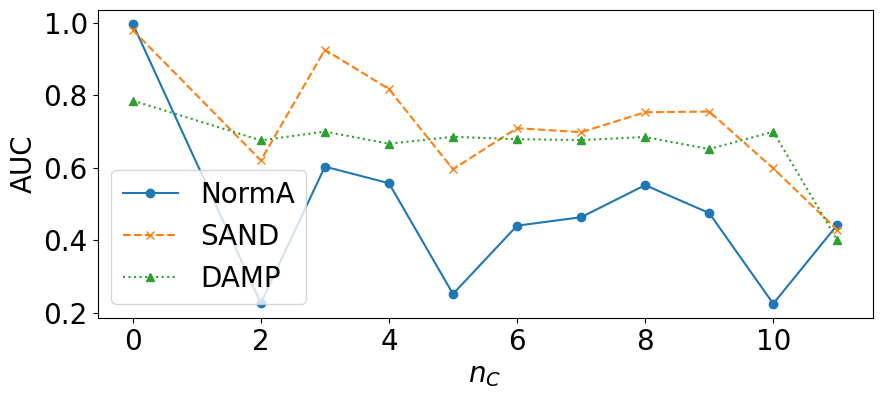

In [ ]:
result_n_drift['n'] = result_n_drift['file'].str.extract(r'_n(\d+)_').astype(int)
plt.rc('font', size=20)
plt.rc('axes', labelsize=20)

x_n_d = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10,11]
plt.figure(figsize=(10,4))
plt.plot(x_n_d, [np.mean(result_org.groupby('method').get_group('NormA')['AUC'])] + list(result_n_drift.groupby('method').get_group('NormA').sort_values(by='n')['AUC']), 'o-', label='NormA')
plt.plot(x_n_d, [np.mean(result_org.groupby('method').get_group('SAND')['AUC'])] + list(result_n_drift.groupby('method').get_group('SAND').sort_values(by='n')['AUC']), 'x--', label='SAND')
plt.plot(x_n_d, [np.mean(result_org.groupby('method').get_group('DAMP')['AUC'])] + list(result_n_drift.groupby('method').get_group('DAMP').sort_values(by='n')['AUC']), '^:', label='DAMP')
plt.xlabel(r'$n_C$')
plt.ylabel('AUC')
# plt.ylim(0.5, 1)
plt.legend()
# plt.savefig(f'{dir}/n_drift_detection.png', bbox_inches='tight')

In [ ]:
base_norma = [np.mean(result_org.groupby('method').get_group('NormA')['AUC'])]
drift_norma = np.mean(result_n_drift.groupby('method').get_group('NormA')['AUC'])
print(f'NormA: {base_norma}, {drift_norma}')

base_sand = [np.mean(result_org.groupby('method').get_group('SAND')['AUC'])]
drift_sand = np.mean(result_n_drift.groupby('method').get_group('SAND')['AUC'])
print(f'SAND: {base_sand}, {drift_sand}')

## DAMP is run on MATLAB and get results file. See the DAMP repo. 
## https://sites.google.com/view/discord-aware-matrix-profile/documentation
base_damp = [np.mean(result_org.groupby('method').get_group('DAMP')['AUC'])]
drift_damp = np.mean(result_n_drift.groupby('method').get_group('DAMP')['AUC'])

print((base_norma - drift_norma)/base_norma, (base_sand - drift_sand)/base_sand)

NormA: [0.9968479775697553], 0.4231954263838971
SAND: [0.979335995710345], 0.6896485077011185
[0.57546643] [0.2957999]


In [ ]:
dir = os.getcwd() + '/data/test_mod/p_drift'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.arff')]
print(filenames)
p_d_labels = []
result_p_drift = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)

with open(f'{dir}/result_p_drift(score)2.pkl', 'rb') as f:
    p_d_scores = pickle.load(f)

for i, file in enumerate(filenames[:8]):
    data, label = read_arff(f'{dir}/{file}')
    # slidingWindow = find_length(data[:10000])
    p_d_labels.append(label)

    r_tmp = result_f1_acc(methods, p_d_scores[i], label.flatten())
    r_tmp['file'] = file
    result_p_drift = pd.concat([result_p_drift, r_tmp])

display(result_p_drift)


['ECGTest_p_d_grad_p29_n10_b50.arff', 'ECGTest_p_d_grad_p4_n10_b50.arff', 'ECGTest_p_d_grad_p14_n9_b50.arff', 'ECGTest_p_d_grad_p19_n10_b50.arff', 'ECGTest_p_d_grad_p9_n10_b50.arff', 'ECGTest_p_d_grad_p24_n10_b50.arff', 'ECGTest_p_d_grad_p34_n10_b50.arff', 'ECGTest_p_d_grad_p44_n10_b50.arff', 'ECGTest_p_d_grad_p49_n10_b50.arff', 'ECGTest_p_d_grad_p39_n10_b50.arff']


,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,ECGTest_p_d_grad_p29_n10_b50.arff,NormA,0.555787,0.075715,0.980178,0.140571,0.241081,0.140148,0.960743,0.244613,0.043022,0.142345,0.076666,0.993511,0.689633
1,ECGTest_p_d_grad_p29_n10_b50.arff,SAND,0.742010,0.392308,0.326400,0.356332,0.752039,0.247509,0.175219,0.205183,0.352089,0.397914,0.425164,0.373956,0.674000
2,ECGTest_p_d_grad_p29_n10_b50.arff,DAMP,0.661783,0.080503,0.567378,0.141000,0.738606,0.060422,0.769224,0.112043,0.069422,0.172704,0.098368,0.707022,0.687092
0,ECGTest_p_d_grad_p4_n10_b50.arff,NormA,0.595433,0.092903,0.986210,0.169810,0.379031,0.362905,0.995546,0.531912,0.018721,0.171979,0.094080,1.000000,0.759763
1,ECGTest_p_d_grad_p4_n10_b50.arff,SAND,0.718875,0.248181,0.401918,0.306872,0.640081,0.280771,0.354385,0.313312,0.293699,0.331817,0.265940,0.441096,0.690172
2,ECGTest_p_d_grad_p4_n10_b50.arff,DAMP,0.706862,0.119585,0.466849,0.190398,0.737617,0.145366,0.674738,0.239199,0.071598,0.270527,0.168008,0.694064,0.761239
0,ECGTest_p_d_grad_p14_n9_b50.arff,NormA,0.594337,0.093427,0.982044,0.170622,0.359222,0.349284,0.922294,0.506682,0.040089,0.172342,0.094361,0.992889,0.751852
1,ECGTest_p_d_grad_p14_n9_b50.arff,SAND,0.807395,0.341252,0.464800,0.393557,0.703456,0.351166,0.248182,0.290826,0.383378,0.434095,0.369558,0.525956,0.739948
2,ECGTest_p_d_grad_p14_n9_b50.arff,DAMP,0.707552,0.112530,0.502044,0.183851,0.752533,0.117108,0.716823,0.201325,0.080622,0.250808,0.152256,0.711111,0.753879
0,ECGTest_p_d_grad_p19_n10_b50.arff,NormA,0.503843,0.072169,0.992978,0.134559,0.303103,0.154262,0.965835,0.266034,0.049422,0.134861,0.072331,0.995378,0.670018


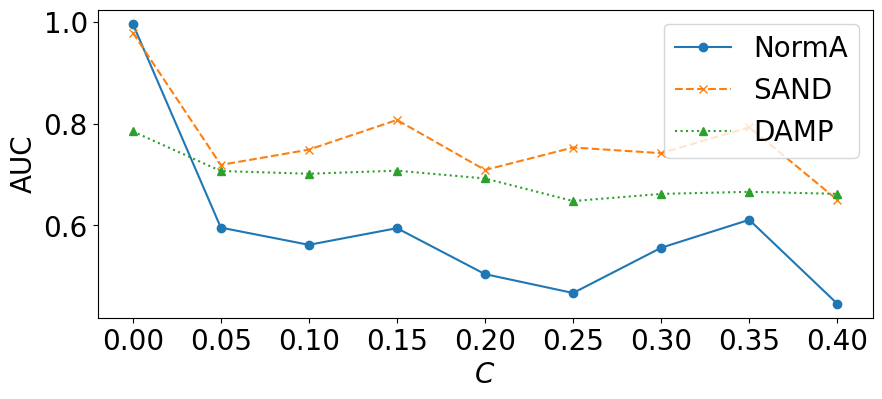

In [ ]:
result_p_drift['p'] = result_p_drift['file'].str.extract(r'_p(\d+)_').astype(int)

plt.rc('font', size=20)
plt.rc('axes', labelsize=20)

x_p_d = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
plt.figure(figsize=(10,4))
plt.plot(x_p_d, [np.mean(result_org.groupby('method').get_group('NormA')['AUC'])] + list(result_p_drift.groupby('method').get_group('NormA').sort_values(by='p')['AUC']), 'o-', label='NormA')
plt.plot(x_p_d, [np.mean(result_org.groupby('method').get_group('SAND')['AUC'])] + list(result_p_drift.groupby('method').get_group('SAND').sort_values(by='p')['AUC']), 'x--', label='SAND')
plt.plot(x_p_d, [np.mean(result_org.groupby('method').get_group('DAMP')['AUC'])] + list(result_p_drift.groupby('method').get_group('DAMP').sort_values(by='p')['AUC']), '^:', label='DAMP')
plt.xlabel(r'$C$')
plt.ylabel('AUC')
# plt.ylim(0.5, 1)
plt.legend()
# plt.show()
plt.savefig(f'{dir}/p_drift_detection.png', bbox_inches='tight')

In [ ]:
result_p_drift.to_csv('./data/test_mod/figs/mod_p_drifts.csv', index=None)

In [ ]:
base_norma = [np.mean(result_org.groupby('method').get_group('NormA')['AUC'])]
drift_norma = np.mean(result_p_drift.groupby('method').get_group('NormA').sort_values(by='p')['AUC'])
print(f'NormA: {base_norma}, {drift_norma}')

base_sand = [np.mean(result_org.groupby('method').get_group('SAND')['AUC'])]
drift_sand = np.mean(result_p_drift.groupby('method').get_group('SAND').sort_values(by='p')['AUC'])
print(f'SAND: {base_sand}, {drift_sand}')

base_damp = [np.mean(result_org.groupby('method').get_group('DAMP')['AUC'])]
drift_damp = np.mean(result_p_drift.groupby('method').get_group('DAMP').sort_values(by='p')['AUC'])

print((base_norma - drift_norma)/base_norma, (base_sand - drift_sand)/base_sand)

NormA: [0.9968479775697553], 0.5417491652880724
SAND: [0.979335995710345], 0.7403031621718027
[0.45653783] [0.24407643]


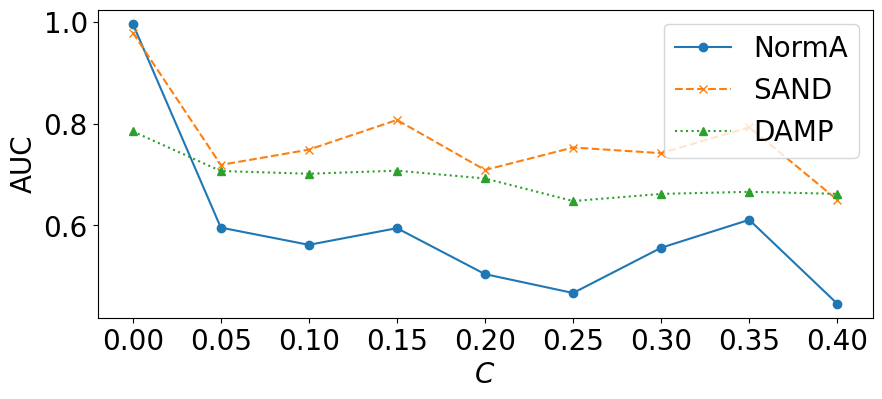

In [ ]:

plt.rc('font', size=20)
plt.rc('axes', labelsize=20)

x_p_d = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
plt.figure(figsize=(10,4))
plt.plot(x_p_d, [np.mean(result_org.groupby('method').get_group('NormA')['AUC'])] + list(result_p_drift.groupby('method').get_group('NormA').sort_values(by='p')['AUC']), 'o-', label='NormA')
plt.plot(x_p_d, [np.mean(result_org.groupby('method').get_group('SAND')['AUC'])] + list(result_p_drift.groupby('method').get_group('SAND').sort_values(by='p')['AUC']), 'x--', label='SAND')
plt.plot(x_p_d, [np.mean(result_org.groupby('method').get_group('DAMP')['AUC'])] + list(result_p_drift.groupby('method').get_group('DAMP').sort_values(by='p')['AUC']), '^:', label='DAMP')
plt.xlabel(r'$C$')
plt.ylabel('AUC')
# plt.ylim(0.5, 1)
plt.legend()
# plt.show()
plt.savefig('p_drift_detection.png', bbox_inches='tight')

In [ ]:
result_p_drift['p'] = result_p_drift['file'].str.extract(r'_p(\d+)_').astype(int)
result_p_drift.groupby('method').get_group('NormA').sort_values(by='p')

,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj,p
0,ECGTest_p_d_grad_p4_n10_b50.arff,NormA,0.595433,0.092903,0.986210,0.169810,0.379031,0.362905,0.995546,0.531912,0.018721,0.171979,0.094080,1.000000,0.759763,4
0,ECGTest_p_d_grad_p9_n10_b50.arff,NormA,0.561545,0.084714,0.966886,0.155779,0.381793,0.344998,0.966701,0.508516,0.008549,0.160445,0.087232,0.998380,0.734482,9
0,ECGTest_p_d_grad_p14_n9_b50.arff,NormA,0.594337,0.093427,0.982044,0.170622,0.359222,0.349284,0.922294,0.506682,0.040089,0.172342,0.094361,0.992889,0.751852,14
0,ECGTest_p_d_grad_p19_n10_b50.arff,NormA,0.503843,0.072169,0.992978,0.134559,0.303103,0.154262,0.965835,0.266034,0.049422,0.134861,0.072331,0.995378,0.670018,19
0,ECGTest_p_d_grad_p24_n10_b50.arff,NormA,0.466708,0.063035,0.936296,0.118117,0.136167,0.087683,0.946173,0.160493,0.025463,0.124906,0.066642,0.993704,0.654621,24
0,ECGTest_p_d_grad_p29_n10_b50.arff,NormA,0.555787,0.075715,0.980178,0.140571,0.241081,0.140148,0.960743,0.244613,0.043022,0.142345,0.076666,0.993511,0.689633,29
0,ECGTest_p_d_grad_p34_n10_b50.arff,NormA,0.610759,0.083609,0.964634,0.153880,0.358095,0.187032,0.890981,0.309165,0.042175,0.155992,0.084749,0.979007,0.735192,34
0,ECGTest_p_d_grad_p44_n10_b50.arff,NormA,0.445581,0.052196,1.000000,0.099214,0.000000,0.000036,0.999866,0.000072,0.062448,0.099213,0.052196,1.000000,0.500000,44


### QDB resuls

In [ ]:
methods = ['NormA', 'SAND', 'DAMP']
dir = os.getcwd() + '/data/test/org'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.arff')]
print(filenames)
org_labels = []
result_org_r = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)

with open('result_org(score).pkl', 'rb') as f:
    org_scores = pickle.load(f)

for i, file in enumerate(filenames):
    data, label = read_arff(f'{dir}/{file}')
    slidingWindow = find_length(data[:10000])
    org_labels.append(label)

    r_tmp = result_f1_acc(methods, org_scores[i], label.flatten())
    r_tmp['file'] = file
    result_org_r = pd.concat([result_org_r, r_tmp])
    # for j, method in enumerate(methods):
        # r_tmp = get_acc(label.reshape(-1), np.array(org_scores[i][j]), slidingWindow)
        # result_org_r.loc[i*len(methods)+j] = [file] + [method] + list(r_tmp.loc[0])

result_org_r
    

['MBA_ECG803_data.arff', 'MBA_ECG805_data.arff', 'MBA_ECG806_data.arff']


,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,MBA_ECG803_data.arff,NormA,0.995282,0.795382,0.902948,0.845758,0.735906,0.793678,0.919565,0.851996,0.835283,0.889166,0.809393,0.986395,0.987360
1,MBA_ECG803_data.arff,SAND,0.980770,0.564684,0.863492,0.682829,0.460946,0.601248,0.879111,0.714102,0.631746,0.724230,0.586861,0.945578,0.956062
2,MBA_ECG803_data.arff,DAMP,0.732088,0.276237,0.594467,0.377198,0.687981,0.192780,0.451610,0.270213,0.133515,0.474679,0.338189,0.795918,0.858821
0,MBA_ECG805_data.arff,NormA,0.973612,0.658639,0.806931,0.725283,0.580761,0.660487,0.867467,0.749958,0.703366,0.825247,0.704336,0.996287,0.978048
1,MBA_ECG805_data.arff,SAND,0.967404,0.604724,0.797277,0.687778,0.445403,0.611476,0.855057,0.713038,0.670644,0.786233,0.654070,0.985347,0.967633
2,MBA_ECG805_data.arff,DAMP,0.806027,0.429122,0.661485,0.520550,0.634295,0.315468,0.646336,0.423991,0.457723,0.688805,0.528813,0.987624,0.951528
0,MBA_ECG806_data.arff,NormA,0.989372,0.581606,0.850211,0.690714,0.220549,0.532328,0.874889,0.661913,0.658420,0.737999,0.606442,0.942463,0.964150
1,MBA_ECG806_data.arff,SAND,0.976662,0.529430,0.643460,0.580902,0.429935,0.404200,0.711616,0.515560,0.575374,0.705208,0.599517,0.856157,0.921457
2,MBA_ECG806_data.arff,DAMP,0.758813,0.068774,0.606828,0.123545,0.462109,0.046688,0.546752,0.086029,0.069428,0.180384,0.100071,0.913694,0.861721


In [ ]:
result_org_r.to_csv('./data/test_mod/org_803_805_real.csv', index=None)

In [ ]:
dir = os.getcwd() + '/data/test/org'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.arff')]

for i, file in enumerate(filenames):
    print(file, list(org_labels[i].reshape(-1)).count(1), len(org_labels[i].reshape(-1)))
    print (file, list(org_labels[i].reshape(-1)).count(1)/len(org_labels[i].reshape(-1)))

MBA_ECG803_data.arff 11025 230400
MBA_ECG803_data.arff 0.0478515625
MBA_ECG805_data.arff 20200 230400
MBA_ECG805_data.arff 0.0876736111111111
MBA_ECG806_data.arff 5214 230400
MBA_ECG806_data.arff 0.022630208333333332


In [ ]:
dir = os.getcwd() + '/data/test/n_drift'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.arff')]
print(filenames)
n_d_labels = []
result_n_drift_r = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)

with open('result_n_drift(score)2.pkl', 'rb') as f:
    n_d_scores_r = pickle.load(f)

for i, file in enumerate(filenames):
    data, label = read_arff(f'{dir}/{file}')    
    slidingWindow = find_length(data[:10000])
    n_d_labels.append(label)

    r_tmp = result_f1_acc(methods, n_d_scores_r[i], label.flatten())
    r_tmp['file'] = file
    result_n_drift_r = pd.concat([result_n_drift_r, r_tmp])
    # for j, method in enumerate(methods):
        # r_tmp = get_acc(label.reshape(-1), np.array(n_d_scores[i][j]), slidingWindow)
        # result_n_drift.loc[i*len(methods)+j] = [file] + [method] + list(r_tmp.loc[0])

result_n_drift_r


['ECGTest_n_d_grad_p19_n2_b50.arff', 'ECGTest_n_d_grad_p19_n5_b40.arff', 'ECGTest_n_d_grad_p19_n10_b50.arff', 'ECGTest_n_d_grad_p19_n6_b42.arff', 'ECGTest_n_d_grad_p19_n5_b50.arff', 'ECGTest_n_d_grad_p19_n4_b50.arff', 'ECGTest_n_d_grad_p19_n11_b45.arff', 'ECGTest_n_d_grad_p19_n9_b44.arff', 'ECGTest_n_d_grad_p19_n7_b50.arff', 'ECGTest_n_d_grad_p19_n3_b33.arff']


,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,ECGTest_n_d_grad_p19_n2_b50.arff,NormA,0.834726,0.163877,0.876111,0.276107,0.540793,0.385161,0.946526,0.547523,0.086957,0.283583,0.168179,0.903762,0.847979
1,ECGTest_n_d_grad_p19_n2_b50.arff,SAND,0.864573,0.464983,0.474841,0.469860,0.593438,0.323188,0.064735,0.107865,0.467709,0.508289,0.490942,0.526917,0.750759
2,ECGTest_n_d_grad_p19_n2_b50.arff,DAMP,0.619724,0.078652,0.678065,0.140954,0.709830,0.055673,0.838368,0.104413,0.014851,0.173905,0.096840,0.851685,0.741215
0,ECGTest_n_d_grad_p19_n5_b40.arff,NormA,0.808284,0.154380,0.772862,0.257353,0.345265,0.147750,0.865030,0.252390,0.096442,0.294246,0.175769,0.902778,0.826713
1,ECGTest_n_d_grad_p19_n5_b40.arff,SAND,0.878480,0.346194,0.513889,0.413693,0.482492,0.252940,0.252636,0.252788,0.392322,0.508720,0.409205,0.672207,0.807521
2,ECGTest_n_d_grad_p19_n5_b40.arff,DAMP,0.824153,0.164952,0.819366,0.274619,0.664549,0.074222,0.820035,0.136124,0.110409,0.306872,0.183636,0.933052,0.844366
0,ECGTest_n_d_grad_p19_n10_b50.arff,NormA,0.800742,0.153144,0.784919,0.256285,0.308658,0.156915,0.918918,0.268056,0.096906,0.298706,0.177651,0.937664,0.839798
1,ECGTest_n_d_grad_p19_n10_b50.arff,SAND,0.859312,0.290672,0.450193,0.353259,0.457520,0.210054,0.322555,0.254422,0.330781,0.470401,0.370067,0.645398,0.790039
2,ECGTest_n_d_grad_p19_n10_b50.arff,DAMP,0.814995,0.173356,0.661408,0.274710,0.766606,0.108186,0.657515,0.185801,0.141995,0.334441,0.209153,0.834107,0.823293
0,ECGTest_n_d_grad_p19_n6_b42.arff,NormA,0.775448,0.167951,0.743528,0.274008,0.307031,0.204116,0.937425,0.335238,0.073259,0.344444,0.209198,0.974437,0.854819


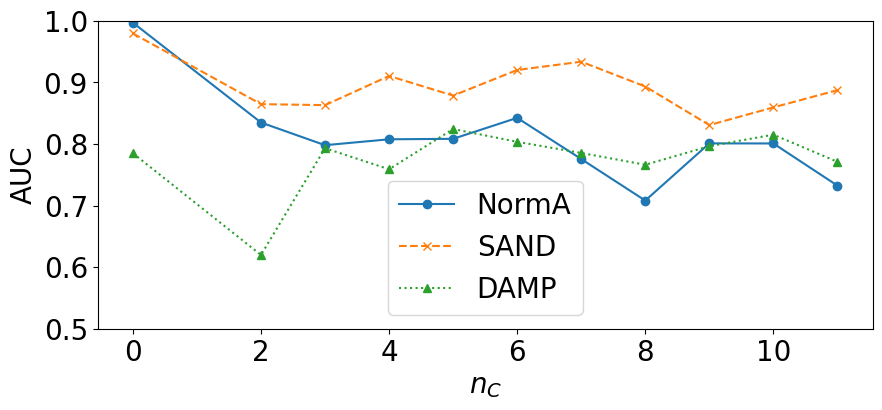

In [ ]:
result_n_drift_r['n'] = result_n_drift_r['file'].str.extract(r'_n(\d+)_').astype(int)
plt.rc('font', size=20)
plt.rc('axes', labelsize=20)

x_n_d = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10,11]
plt.figure(figsize=(10,4))
plt.plot(x_n_d, [np.mean(result_org.groupby('method').get_group('NormA')['AUC'])] + list(result_n_drift_r.groupby('method').get_group('NormA').sort_values(by='n')['AUC']), 'o-', label='NormA')
plt.plot(x_n_d, [np.mean(result_org.groupby('method').get_group('SAND')['AUC'])] + list(result_n_drift_r.groupby('method').get_group('SAND').sort_values(by='n')['AUC']), 'x--', label='SAND')
plt.plot(x_n_d, [np.mean(result_org.groupby('method').get_group('DAMP')['AUC'])] + list(result_n_drift_r.groupby('method').get_group('DAMP').sort_values(by='n')['AUC']), '^:', label='DAMP')
plt.xlabel(r'$n_C$')
plt.ylabel('AUC')
plt.ylim(0.5, 1)
plt.legend()
plt.savefig('n_drift_detection.png', bbox_inches='tight')

In [ ]:
result_n_drift_r.to_csv('./data/test_mod/org_n_drift_real.csv', index=None)

In [ ]:
dir = os.getcwd() + '/data/test/p_drift'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.arff')]
print(filenames)
p_d_labels2 = []
result_p_drift_r = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)

with open('result_p_drift(score)2.pkl', 'rb') as f:
    p_d_scores_r = pickle.load(f)

for i, file in enumerate(filenames[:8]):
    data, label = read_arff(f'{dir}/{file}')
    slidingWindow = find_length(data[:10000])
    p_d_labels2.append(label)

    r_tmp = result_f1_acc(methods, p_d_scores_r[i], label.flatten())
    r_tmp['file'] = file
    result_p_drift_r = pd.concat([result_p_drift_r, r_tmp])

    # for j, method in enumerate(methods):
        # r_tmp = get_acc(label.reshape(-1), np.array(p_d_scores2[i][j]), slidingWindow)
        # result_p_drift2.loc[i*len(methods)+j] = [file] + [method] + list(r_tmp.loc[0])

display(result_p_drift_r)


['ECGTest_p_d_grad_p29_n10_b50.arff', 'ECGTest_p_d_grad_p4_n10_b50.arff', 'ECGTest_p_d_grad_p14_n10_b50.arff', 'ECGTest_p_d_grad_p9_n10_b50.arff', 'ECGTest_p_d_grad_p24_n10_b50.arff', 'ECGTest_p_d_grad_p34_n10_b50.arff', 'ECGTest_p_d_grad_p19_n9_b50.arff', 'ECGTest_p_d_grad_p44_n9_b50.arff', 'ECGTest_p_d_grad_p49_n10_b50.arff', 'ECGTest_p_d_grad_p39_n10_b50.arff']


,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,ECGTest_p_d_grad_p29_n10_b50.arff,NormA,0.696246,0.112423,0.579583,0.188318,0.392623,0.081339,0.847528,0.148433,0.054804,0.221951,0.132028,0.696024,0.694491
1,ECGTest_p_d_grad_p29_n10_b50.arff,SAND,0.867277,0.383008,0.404818,0.393611,0.588244,0.263518,0.161705,0.200423,0.391151,0.468777,0.436814,0.505798,0.731020
2,ECGTest_p_d_grad_p29_n10_b50.arff,DAMP,0.724037,0.137483,0.742891,0.232026,0.739532,0.059920,0.738808,0.110850,0.071853,0.262752,0.155192,0.856157,0.771711
0,ECGTest_p_d_grad_p4_n10_b50.arff,NormA,0.894115,0.358975,0.795967,0.494800,0.313140,0.414444,0.910671,0.569645,0.333215,0.535938,0.384090,0.886381,0.896741
1,ECGTest_p_d_grad_p4_n10_b50.arff,SAND,0.938782,0.404806,0.671029,0.504978,0.451888,0.420882,0.794831,0.550343,0.480297,0.631792,0.481812,0.917368,0.926441
2,ECGTest_p_d_grad_p4_n10_b50.arff,DAMP,0.813981,0.268450,0.581323,0.367289,0.728254,0.161215,0.733051,0.264304,0.292466,0.498402,0.351340,0.857234,0.876896
0,ECGTest_p_d_grad_p14_n10_b50.arff,NormA,0.847971,0.221568,0.853094,0.351773,0.445093,0.299479,0.881385,0.447057,0.111219,0.384453,0.240913,0.951216,0.875473
1,ECGTest_p_d_grad_p14_n10_b50.arff,SAND,0.905039,0.367295,0.562816,0.444505,0.575792,0.369407,0.387798,0.378379,0.418128,0.540923,0.429591,0.730164,0.832691
2,ECGTest_p_d_grad_p14_n10_b50.arff,DAMP,0.750437,0.172620,0.736401,0.279680,0.722484,0.089016,0.701079,0.157974,0.083778,0.327865,0.201042,0.888157,0.826154
0,ECGTest_p_d_grad_p9_n10_b50.arff,NormA,0.881420,0.277002,0.779005,0.408683,0.369181,0.364922,0.865110,0.513317,0.168743,0.471062,0.314895,0.934550,0.897231


In [ ]:
# result_p_rev_r = result_p_drift_r
# result_p_rev_r.loc[3] = result_p_drift_r1.loc[12]
# result_p_rev_r.loc[4] = result_p_drift_r1.loc[13]
# result_p_rev_r.loc[5] = result_p_drift_r1.loc[14]
# result_p_rev_r

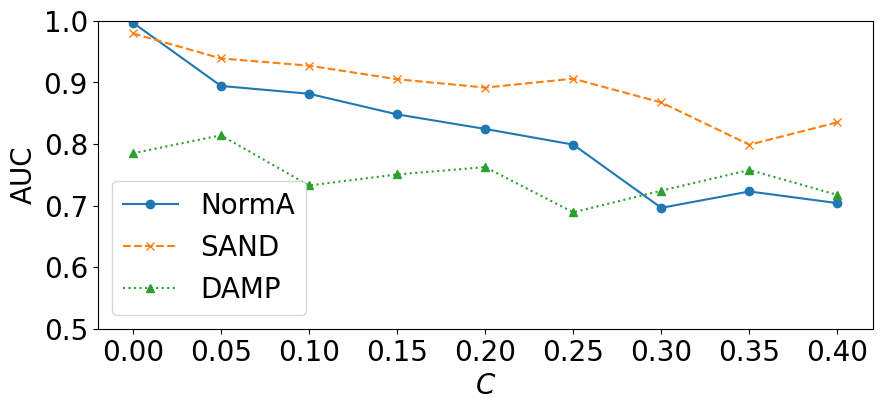

In [ ]:
result_p_drift_r['p'] = result_p_drift_r['file'].str.extract(r'_p(\d+)_').astype(int)
plt.rc('font', size=20)
plt.rc('axes', labelsize=20)

x_p_d = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
plt.figure(figsize=(10,4))
plt.plot(x_p_d, [np.mean(result_org.groupby('method').get_group('NormA')['AUC'])] + list(result_p_drift_r.groupby('method').get_group('NormA').sort_values(by='p')['AUC']), 'o-', label='NormA')
plt.plot(x_p_d, [np.mean(result_org.groupby('method').get_group('SAND')['AUC'])] + list(result_p_drift_r.groupby('method').get_group('SAND').sort_values(by='p')['AUC']), 'x--', label='SAND')
plt.plot(x_p_d, [np.mean(result_org.groupby('method').get_group('DAMP')['AUC'])] + list(result_p_drift_r.groupby('method').get_group('DAMP').sort_values(by='p')['AUC']), '^:', label='DAMP')
plt.xlabel(r'$C$')
plt.ylabel('AUC')
plt.ylim(0.5, 1)
plt.legend()
# plt.show()
plt.savefig('p_drift_detection.png', bbox_inches='tight')

In [ ]:
result_p_drift_r.to_csv('./data/test_mod/org_p_drift_real.csv', index=None)

### For reading DAMP results by Matlab code 

In [ ]:
dir = os.getcwd() + '/data/test/org'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.csv')]
filenames.sort()
print(filenames)

filenames_data = [file for file in all_files if file.endswith('arff')]
filenames_data.sort()
print(filenames_data)

result_org_damp = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)
scores, labels, datas, sls = [], [], [], []

for i, (file, file_data) in enumerate(zip(filenames, filenames_data)):
    df = pd.read_csv(f'{dir}/{file}')
    score = df.iloc[:,0].to_numpy()

    # label = org_labels[i]
    data, label = read_arff(f'{dir}/{file_data}')
    slidingWindow = find_length(data.reshape(-1)[:10000])
    sls.append(slidingWindow)
    print(slidingWindow)
    datas.append(data)
    labels.append(label)

    score = running_mean(score, slidingWindow)
    score = np.array([score[0]]*math.ceil((slidingWindow-1)) + list(score))
    scores.append(score)

    r_tmp = result_f1_acc(['DAMP'], [score], label.flatten())
    r_tmp['file'] = file
    result_org_damp = pd.concat([result_org_damp, r_tmp])

result_org_damp

['MBA_ECG803_data_score.csv', 'MBA_ECG805_data_score.csv', 'MBA_ECG806_data_score.csv', 'damp_real.csv']
['MBA_ECG803_data.arff', 'MBA_ECG805_data.arff', 'MBA_ECG806_data.arff']
108
99
78


,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,MBA_ECG803_data_score.csv,DAMP,0.883833,0.721371,0.555374,0.627582,0.683045,0.725135,0.566676,0.636187,0.599909,0.670303,0.740538,0.612245,0.800732
0,MBA_ECG805_data_score.csv,DAMP,0.815013,0.405507,0.547475,0.465917,0.231937,0.391941,0.567517,0.463664,0.448366,0.536656,0.451652,0.661089,0.791979
0,MBA_ECG806_data_score.csv,DAMP,0.989693,0.533741,0.820675,0.646814,0.253374,0.493978,0.852920,0.625621,0.603951,0.701757,0.564183,0.928078,0.955739


In [ ]:
result_org_damp.to_csv('./data/test/org/damp_real.csv', index=None)
# result_org_damp['n'] = result_org_damp['file'].str.extract(r'_n(\d+)_').astype(int)
# result_n_drift_r.to_csv('./data/test_mod/org_n_drift_real.csv', index=None)

In [ ]:
dir = os.getcwd() + '/data/test/n_drift'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.csv')]
filenames.sort()
print(filenames)

filenames_data = [file for file in all_files if file.endswith('arff')]
filenames_data.sort()
print(filenames_data)

result_n_drift_r_damp = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)
scores, labels, datas, sls = [], [], [], []

for i, (file, file_data) in enumerate(zip(filenames, filenames_data)):
    df = pd.read_csv(f'{dir}/{file}')
    score = df.iloc[:,0].to_numpy()

    # label = org_labels[i]
    data, label = read_arff(f'{dir}/{file_data}')
    slidingWindow = find_length(data.reshape(-1)[:10000])
    sls.append(slidingWindow)
    print(slidingWindow)
    datas.append(data)
    labels.append(label)

    score = running_mean(score, slidingWindow)
    score = np.array([score[0]]*math.ceil((slidingWindow-1)) + list(score))
    scores.append(score)

    r_tmp = result_f1_acc(['DAMP'], [score], label.flatten())
    r_tmp['file'] = file
    result_n_drift_r_damp = pd.concat([result_n_drift_r_damp, r_tmp])

result_n_drift_r_damp

['ECGTest_n_d_grad_p19_n10_b50_score.csv', 'ECGTest_n_d_grad_p19_n11_b45_score.csv', 'ECGTest_n_d_grad_p19_n2_b50_score.csv', 'ECGTest_n_d_grad_p19_n3_b33_score.csv', 'ECGTest_n_d_grad_p19_n4_b50_score.csv', 'ECGTest_n_d_grad_p19_n5_b40_score.csv', 'ECGTest_n_d_grad_p19_n5_b50_score.csv', 'ECGTest_n_d_grad_p19_n6_b42_score.csv', 'ECGTest_n_d_grad_p19_n7_b50_score.csv', 'ECGTest_n_d_grad_p19_n9_b44_score.csv']
['ECGTest_n_d_grad_p19_n10_b50.arff', 'ECGTest_n_d_grad_p19_n11_b45.arff', 'ECGTest_n_d_grad_p19_n2_b50.arff', 'ECGTest_n_d_grad_p19_n3_b33.arff', 'ECGTest_n_d_grad_p19_n4_b50.arff', 'ECGTest_n_d_grad_p19_n5_b40.arff', 'ECGTest_n_d_grad_p19_n5_b50.arff', 'ECGTest_n_d_grad_p19_n6_b42.arff', 'ECGTest_n_d_grad_p19_n7_b50.arff', 'ECGTest_n_d_grad_p19_n9_b44.arff']
78
99
108
78
108
78
99
99
99
78


,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,ECGTest_n_d_grad_p19_n10_b50_score.csv,DAMP,0.733517,0.126833,0.491725,0.201652,0.538007,0.131228,0.823224,0.226370,0.122660,0.224679,0.140852,0.554988,0.676857
0,ECGTest_n_d_grad_p19_n11_b45_score.csv,DAMP,0.750544,0.172510,0.449182,0.249282,0.654457,0.240786,0.707635,0.359309,0.220251,0.293301,0.201033,0.542139,0.705939
0,ECGTest_n_d_grad_p19_n2_b50_score.csv,DAMP,0.809623,0.141810,0.659893,0.233452,0.673243,0.247533,0.856771,0.384095,0.094871,0.248734,0.150814,0.709233,0.761793
0,ECGTest_n_d_grad_p19_n3_b33_score.csv,DAMP,0.737488,0.126716,0.544947,0.205620,0.498277,0.140564,0.912548,0.243605,0.108769,0.222000,0.136523,0.593787,0.678951
0,ECGTest_n_d_grad_p19_n4_b50_score.csv,DAMP,0.716826,0.217643,0.348119,0.267836,0.742075,0.246728,0.538829,0.338471,0.251059,0.320463,0.255556,0.429580,0.669417
0,ECGTest_n_d_grad_p19_n5_b40_score.csv,DAMP,0.743362,0.139840,0.453105,0.213721,0.574637,0.149114,0.726769,0.247456,0.096988,0.248494,0.161624,0.537297,0.686567
0,ECGTest_n_d_grad_p19_n5_b50_score.csv,DAMP,0.832873,0.223958,0.593494,0.325200,0.603205,0.278667,0.760256,0.407842,0.246895,0.352166,0.241066,0.653232,0.770937
0,ECGTest_n_d_grad_p19_n6_b42_score.csv,DAMP,0.774406,0.287354,0.383963,0.328707,0.696209,0.297814,0.603205,0.398755,0.309280,0.388607,0.330847,0.470813,0.701179
0,ECGTest_n_d_grad_p19_n7_b50_score.csv,DAMP,0.727448,0.181156,0.375254,0.244350,0.642685,0.234938,0.747647,0.357527,0.211492,0.278689,0.204684,0.436534,0.653967
0,ECGTest_n_d_grad_p19_n9_b44_score.csv,DAMP,0.730166,0.105071,0.527218,0.175221,0.424682,0.124628,0.893544,0.218747,0.109905,0.193064,0.115546,0.586649,0.674180


In [ ]:
result_n_drift_r_damp['n'] = result_n_drift_r_damp['file'].str.extract(r'_n(\d+)_').astype(int)
result_n_drift_r_damp.to_csv('./data/test/damp_real_n_drift.csv', index=None)

In [ ]:
dir = os.getcwd() + '/data/test/p_drift'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.csv')]
filenames.sort()
print(filenames)

filenames_data = [file for file in all_files if file.endswith('arff')]
filenames_data.sort()
print(filenames_data)

result_p_drift_r_damp = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)
scores, labels, datas, sls = [], [], [], []

for i, (file, file_data) in enumerate(zip(filenames, filenames_data)):
# for i, file_data in enumerate(filenames_data):
    df = pd.read_csv(f'{dir}/{file}')
    score = df.iloc[:,0].to_numpy()

    # label = org_labels[i]
    print(file_data)
    data, label = read_arff(f'{dir}/{file_data}')
    slidingWindow = find_length(data.reshape(-1)[:10000])
    sls.append(slidingWindow)
    print(slidingWindow)
    datas.append(data)
    labels.append(label)

    score = running_mean(score, slidingWindow)
    score = np.array([score[0]]*math.ceil((slidingWindow-1)) + list(score))
    scores.append(score)

    r_tmp = result_f1_acc(['DAMP'], [score], label.flatten())
    r_tmp['file'] = file
    result_p_drift_r_damp = pd.concat([result_p_drift_r_damp, r_tmp])

result_p_drift_r_damp

['ECGTest_p_d_grad_p14_n10_b50_score.csv', 'ECGTest_p_d_grad_p19_n9_b50_score.csv', 'ECGTest_p_d_grad_p24_n10_b50_score.csv', 'ECGTest_p_d_grad_p29_n10_b50_score.csv', 'ECGTest_p_d_grad_p34_n10_b50_score.csv', 'ECGTest_p_d_grad_p39_n10_b50_score.csv', 'ECGTest_p_d_grad_p44_n9_b50_score.csv', 'ECGTest_p_d_grad_p49_n10_b50_score.csv', 'ECGTest_p_d_grad_p4_n10_b50_score.csv', 'ECGTest_p_d_grad_p9_n10_b50_score.csv']
['ECGTest_p_d_grad_p14_n10_b50.arff', 'ECGTest_p_d_grad_p19_n9_b50.arff', 'ECGTest_p_d_grad_p24_n10_b50.arff', 'ECGTest_p_d_grad_p29_n10_b50.arff', 'ECGTest_p_d_grad_p34_n10_b50.arff', 'ECGTest_p_d_grad_p39_n10_b50.arff', 'ECGTest_p_d_grad_p44_n9_b50.arff', 'ECGTest_p_d_grad_p49_n10_b50.arff', 'ECGTest_p_d_grad_p4_n10_b50.arff', 'ECGTest_p_d_grad_p9_n10_b50.arff']
ECGTest_p_d_grad_p14_n10_b50.arff
108
ECGTest_p_d_grad_p19_n9_b50.arff
99
ECGTest_p_d_grad_p24_n10_b50.arff
108
ECGTest_p_d_grad_p29_n10_b50.arff
108
ECGTest_p_d_grad_p34_n10_b50.arff
99
ECGTest_p_d_grad_p39_n10_b50.

,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,ECGTest_p_d_grad_p14_n10_b50_score.csv,DAMP,0.748264,0.276026,0.334211,0.302345,0.739447,0.298686,0.551876,0.387597,0.294436,0.370082,0.327092,0.426097,0.683762
0,ECGTest_p_d_grad_p19_n9_b50_score.csv,DAMP,0.730968,0.223755,0.434263,0.295337,0.678966,0.273885,0.776622,0.404957,0.242271,0.329852,0.247327,0.495044,0.694186
0,ECGTest_p_d_grad_p24_n10_b50_score.csv,DAMP,0.711415,0.199269,0.300299,0.239568,0.747797,0.153724,0.515241,0.236798,0.224634,0.288742,0.235804,0.372345,0.650934
0,ECGTest_p_d_grad_p29_n10_b50_score.csv,DAMP,0.741521,0.198559,0.365337,0.257285,0.739587,0.183455,0.460217,0.262336,0.229431,0.297823,0.226978,0.432979,0.667015
0,ECGTest_p_d_grad_p34_n10_b50_score.csv,DAMP,0.736853,0.150805,0.285165,0.197281,0.794620,0.091754,0.418298,0.150497,0.166583,0.259165,0.194581,0.387941,0.650018
0,ECGTest_p_d_grad_p39_n10_b50_score.csv,DAMP,0.636647,0.109130,0.482307,0.177988,0.567147,0.073843,0.781091,0.134929,0.085833,0.204332,0.124876,0.561826,0.641825
0,ECGTest_p_d_grad_p44_n9_b50_score.csv,DAMP,0.725431,0.150719,0.375282,0.215065,0.726838,0.083158,0.463984,0.141038,0.176236,0.245066,0.170596,0.434952,0.661776
0,ECGTest_p_d_grad_p49_n10_b50_score.csv,DAMP,0.669289,0.088423,0.811650,0.159473,0.415473,0.055599,0.944254,0.105015,0.085015,0.166209,0.092122,0.849050,0.665097
0,ECGTest_p_d_grad_p4_n10_b50_score.csv,DAMP,0.812350,0.283272,0.407924,0.334358,0.451702,0.355501,0.852279,0.501723,0.323240,0.357028,0.299650,0.441599,0.687070
0,ECGTest_p_d_grad_p9_n10_b50_score.csv,DAMP,0.762275,0.287806,0.316275,0.301370,0.700176,0.349928,0.560115,0.430749,0.297758,0.348003,0.324244,0.375530,0.660804


In [ ]:
result_p_drift_r_damp['p'] = result_p_drift_r_damp['file'].str.extract(r'_p(\d+)_').astype(int)
result_p_drift_r_damp.to_csv('./data/test/damp_real_p_drift.csv', index=None)

In [ ]:
dir = os.getcwd() + '/data/test_mod/org'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.csv')]
filenames.sort()
print(filenames)

filenames_data = [file for file in all_files if file.endswith('arff')]
filenames_data.sort()
print(filenames_data)

result_org_damp_mod = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)
scores, labels, datas, sls = [], [], [], []

for i, (file, file_data) in enumerate(zip(filenames, filenames_data)):
    df = pd.read_csv(f'{dir}/{file}')
    score = df.iloc[:,0].to_numpy()

    # label = org_labels[i]
    data, label = read_arff(f'{dir}/{file_data}')
    slidingWindow = find_length(data.reshape(-1)[:10000])
    sls.append(slidingWindow)
    print(slidingWindow)
    datas.append(data)
    labels.append(label)

    score = running_mean(score, slidingWindow)
    score = np.array([score[0]]*math.ceil((slidingWindow-1)) + list(score))
    scores.append(score)

    r_tmp = result_f1_acc(['DAMP'], [score], label.flatten())
    r_tmp['file'] = file
    result_org_damp_mod = pd.concat([result_org_damp_mod, r_tmp])

result_org_damp_mod

['MBA_ECG803_data_score.csv', 'damp_real.csv']
['MBA_ECG803_data.arff']
108


,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,MBA_ECG803_data_score.csv,DAMP,0.883833,0.721371,0.555374,0.627582,0.683045,0.725135,0.566676,0.636187,0.599909,0.670303,0.740538,0.612245,0.800732


In [ ]:
result_org_damp_mod.to_csv('./data/test_mod/org/damp_real.csv', index=None)
# result_org_damp['n'] = result_org_damp['file'].str.extract(r'_n(\d+)_').astype(int)
# result_n_drift_r.to_csv('./data/test_mod/org_n_drift_real.csv', index=None)

In [ ]:
dir = os.getcwd() + '/data/test_mod/n_drift'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.csv')]
filenames.sort()
print(filenames)

filenames_data = [file for file in all_files if file.endswith('arff')]
filenames_data.sort()
print(filenames_data)

result_n_drift_mod_damp = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)
scores, labels, datas, sls = [], [], [], []

for i, (file, file_data) in enumerate(zip(filenames, filenames_data)):
    df = pd.read_csv(f'{dir}/{file}')
    score = df.iloc[:,0].to_numpy()

    # label = org_labels[i]
    data, label = read_arff(f'{dir}/{file_data}')
    slidingWindow = find_length(data.reshape(-1)[:10000])
    if slidingWindow < 20: slidingWindow = 108
    sls.append(slidingWindow)
    print(slidingWindow)
    datas.append(data)
    labels.append(label)

    score = running_mean(score, slidingWindow)
    score = np.array([score[0]]*math.ceil((slidingWindow-1)) + list(score))
    scores.append(score)

    r_tmp = result_f1_acc(['DAMP'], [score], label.flatten())
    r_tmp['file'] = file
    result_n_drift_mod_damp = pd.concat([result_n_drift_mod_damp, r_tmp])

result_n_drift_mod_damp

['ECGTest_n_d_grad_p19_n10_b45_score.csv', 'ECGTest_n_d_grad_p19_n11_b45_score.csv', 'ECGTest_n_d_grad_p19_n2_b50_score.csv', 'ECGTest_n_d_grad_p19_n3_b33_score.csv', 'ECGTest_n_d_grad_p19_n4_b50_score.csv', 'ECGTest_n_d_grad_p19_n5_b40_score.csv', 'ECGTest_n_d_grad_p19_n6_b50_score.csv', 'ECGTest_n_d_grad_p19_n7_b42_score.csv', 'ECGTest_n_d_grad_p19_n8_b50_score.csv', 'ECGTest_n_d_grad_p19_n9_b44_score.csv']
['ECGTest_n_d_grad_p19_n10_b45.arff', 'ECGTest_n_d_grad_p19_n11_b45.arff', 'ECGTest_n_d_grad_p19_n2_b50.arff', 'ECGTest_n_d_grad_p19_n3_b33.arff', 'ECGTest_n_d_grad_p19_n4_b50.arff', 'ECGTest_n_d_grad_p19_n5_b40.arff', 'ECGTest_n_d_grad_p19_n6_b50.arff', 'ECGTest_n_d_grad_p19_n7_b42.arff', 'ECGTest_n_d_grad_p19_n8_b50.arff', 'ECGTest_n_d_grad_p19_n9_b44.arff']
109
108
109
108
109
109
109
109
108
108


,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,ECGTest_n_d_grad_p19_n10_b45_score.csv,DAMP,0.643477,0.092362,0.525591,0.157115,0.739505,0.102882,0.670271,0.178383,0.035065,0.188729,0.110615,0.642379,0.696536
0,ECGTest_n_d_grad_p19_n11_b45_score.csv,DAMP,0.703219,0.118381,0.588235,0.197096,0.713323,0.152166,0.609125,0.243503,0.051437,0.212337,0.127319,0.639132,0.708687
0,ECGTest_n_d_grad_p19_n2_b50_score.csv,DAMP,0.611318,0.079347,0.597379,0.140087,0.702089,0.089825,0.720461,0.159735,0.052869,0.153818,0.087040,0.660822,0.655575
0,ECGTest_n_d_grad_p19_n3_b33_score.csv,DAMP,0.769544,0.143522,0.638161,0.234341,0.545901,0.311257,0.816448,0.450695,0.042483,0.242941,0.148628,0.664828,0.738085
0,ECGTest_n_d_grad_p19_n4_b50_score.csv,DAMP,0.723407,0.132617,0.488858,0.208635,0.740486,0.195262,0.590576,0.293488,0.065734,0.231364,0.146562,0.549091,0.696493
0,ECGTest_n_d_grad_p19_n5_b40_score.csv,DAMP,0.655154,0.097086,0.566366,0.165758,0.708178,0.108632,0.770851,0.190428,0.076215,0.190852,0.111524,0.661161,0.690637
0,ECGTest_n_d_grad_p19_n6_b50_score.csv,DAMP,0.646925,0.095414,0.618649,0.165329,0.709779,0.115563,0.755935,0.200478,0.053741,0.185263,0.106740,0.700863,0.700041
0,ECGTest_n_d_grad_p19_n7_b42_score.csv,DAMP,0.673811,0.112474,0.610932,0.189973,0.714555,0.142525,0.771421,0.240598,0.063302,0.210186,0.124187,0.683576,0.715700
0,ECGTest_n_d_grad_p19_n8_b50_score.csv,DAMP,0.712146,0.122447,0.515572,0.197894,0.712462,0.185800,0.711933,0.294691,0.061214,0.224693,0.138541,0.594237,0.702950
0,ECGTest_n_d_grad_p19_n9_b44_score.csv,DAMP,0.679601,0.106772,0.559002,0.179298,0.703709,0.178123,0.799252,0.291321,0.059955,0.187914,0.111804,0.588662,0.676819


In [ ]:
result_n_drift_mod_damp['n'] = result_n_drift_mod_damp['file'].str.extract(r'_n(\d+)_').astype(int)
result_n_drift_mod_damp.to_csv('./data/test_mod/damp_mod_n_drift.csv', index=None)

In [ ]:
dir = os.getcwd() + '/data/test_mod/p_drift'
all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.csv')]
filenames.sort()
print(filenames)

filenames_data = [file for file in all_files if file.endswith('arff')]
filenames_data.sort()
print(filenames_data)

result_p_drift_mod_damp = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)
scores, labels, datas, sls = [], [], [], []

for i, (file, file_data) in enumerate(zip(filenames, filenames_data)):
# for i, file_data in enumerate(filenames_data):
    df = pd.read_csv(f'{dir}/{file}')
    score = df.iloc[:,0].to_numpy()

    # label = org_labels[i]
    print(file_data)
    data, label = read_arff(f'{dir}/{file_data}')
    slidingWindow = find_length(data.reshape(-1)[:10000])
    sls.append(slidingWindow)
    print(slidingWindow)
    datas.append(data)
    labels.append(label)

    score = running_mean(score, slidingWindow)
    score = np.array([score[0]]*math.ceil((slidingWindow-1)) + list(score))
    scores.append(score)

    r_tmp = result_f1_acc(['DAMP'], [score], label.flatten())
    r_tmp['file'] = file
    result_p_drift_mod_damp = pd.concat([result_p_drift_mod_damp, r_tmp])

result_p_drift_mod_damp

['ECGTest_p_d_grad_p14_n9_b50_score.csv', 'ECGTest_p_d_grad_p19_n10_b50_score.csv', 'ECGTest_p_d_grad_p24_n10_b50_score.csv', 'ECGTest_p_d_grad_p29_n10_b50_score.csv', 'ECGTest_p_d_grad_p34_n10_b50_score.csv', 'ECGTest_p_d_grad_p39_n10_b50_score.csv', 'ECGTest_p_d_grad_p44_n10_b50_score.csv', 'ECGTest_p_d_grad_p49_n10_b50_score.csv', 'ECGTest_p_d_grad_p4_n10_b50_score.csv', 'ECGTest_p_d_grad_p9_n10_b50_score.csv']
['ECGTest_p_d_grad_p14_n9_b50.arff', 'ECGTest_p_d_grad_p19_n10_b50.arff', 'ECGTest_p_d_grad_p24_n10_b50.arff', 'ECGTest_p_d_grad_p29_n10_b50.arff', 'ECGTest_p_d_grad_p34_n10_b50.arff', 'ECGTest_p_d_grad_p39_n10_b50.arff', 'ECGTest_p_d_grad_p44_n10_b50.arff', 'ECGTest_p_d_grad_p49_n10_b50.arff', 'ECGTest_p_d_grad_p4_n10_b50.arff', 'ECGTest_p_d_grad_p9_n10_b50.arff']
ECGTest_p_d_grad_p14_n9_b50.arff
108
ECGTest_p_d_grad_p19_n10_b50.arff
110
ECGTest_p_d_grad_p24_n10_b50.arff
109
ECGTest_p_d_grad_p29_n10_b50.arff
108
ECGTest_p_d_grad_p34_n10_b50.arff
109
ECGTest_p_d_grad_p39_n10_

,file,method,AUC,Precision,Recall,F1,TH,RPrecision,RRecall,RF1,PaK,F1_adj,Precision_adj,Recall_adj,roc_auc_adj
0,ECGTest_p_d_grad_p14_n9_b50_score.csv,DAMP,0.755690,0.153969,0.581156,0.243442,0.691779,0.246660,0.706966,0.365720,0.089067,0.255230,0.161140,0.613422,0.724746
0,ECGTest_p_d_grad_p19_n10_b50_score.csv,DAMP,0.709618,0.116582,0.565333,0.193301,0.720096,0.134075,0.638439,0.221611,0.075378,0.205759,0.123921,0.605956,0.693021
0,ECGTest_p_d_grad_p24_n10_b50_score.csv,DAMP,0.672064,0.097016,0.640000,0.168491,0.688387,0.137451,0.755035,0.232565,0.035556,0.175892,0.101217,0.670833,0.688936
0,ECGTest_p_d_grad_p29_n10_b50_score.csv,DAMP,0.687994,0.102214,0.580178,0.173808,0.723155,0.103120,0.753971,0.181427,0.065422,0.185138,0.108760,0.621867,0.680134
0,ECGTest_p_d_grad_p34_n10_b50_score.csv,DAMP,0.706956,0.102661,0.608889,0.175699,0.721488,0.113614,0.670710,0.194313,0.077920,0.184193,0.107542,0.641324,0.692646
0,ECGTest_p_d_grad_p39_n10_b50_score.csv,DAMP,0.642599,0.078253,0.579609,0.137890,0.753280,0.036352,0.703473,0.069132,0.070020,0.145432,0.082489,0.613805,0.634872
0,ECGTest_p_d_grad_p44_n10_b50_score.csv,DAMP,0.663396,0.085003,0.748025,0.152658,0.696755,0.043316,0.858892,0.082472,0.080748,0.158049,0.087976,0.776715,0.666662
0,ECGTest_p_d_grad_p49_n10_b50_score.csv,DAMP,0.613845,0.074666,0.626205,0.133423,0.730320,0.029164,0.804581,0.056287,0.069439,0.140476,0.078579,0.661817,0.632572
0,ECGTest_p_d_grad_p4_n10_b50_score.csv,DAMP,0.751945,0.200838,0.437534,0.275305,0.710436,0.304350,0.652068,0.415001,0.153333,0.319010,0.230048,0.520183,0.716655
0,ECGTest_p_d_grad_p9_n10_b50_score.csv,DAMP,0.744830,0.164155,0.520472,0.249590,0.705299,0.269440,0.733263,0.394076,0.072078,0.272251,0.178333,0.575182,0.720439


In [ ]:
result_p_drift_mod_damp['p'] = result_p_drift_mod_damp['file'].str.extract(r'_p(\d+)_').astype(int)
result_p_drift_mod_damp.to_csv('./data/test_mod/damp_mod_p_drift.csv', index=None)

NameError: name 'score1' is not defined

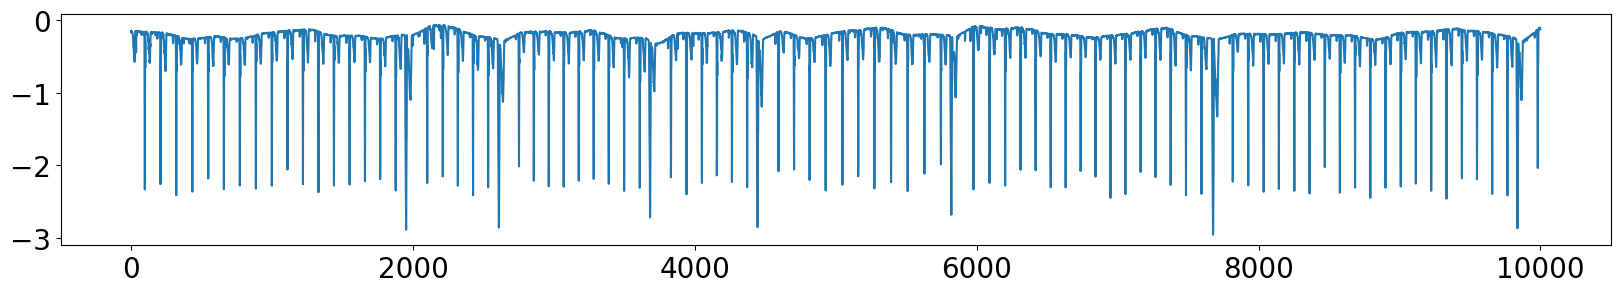

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,3))
plt.plot(datas[0][:10000])
# plt.plot(scores[0][:10000])
plt.plot(score1[:10000])
plt.plot(labels[0][:10000])

### Final fig

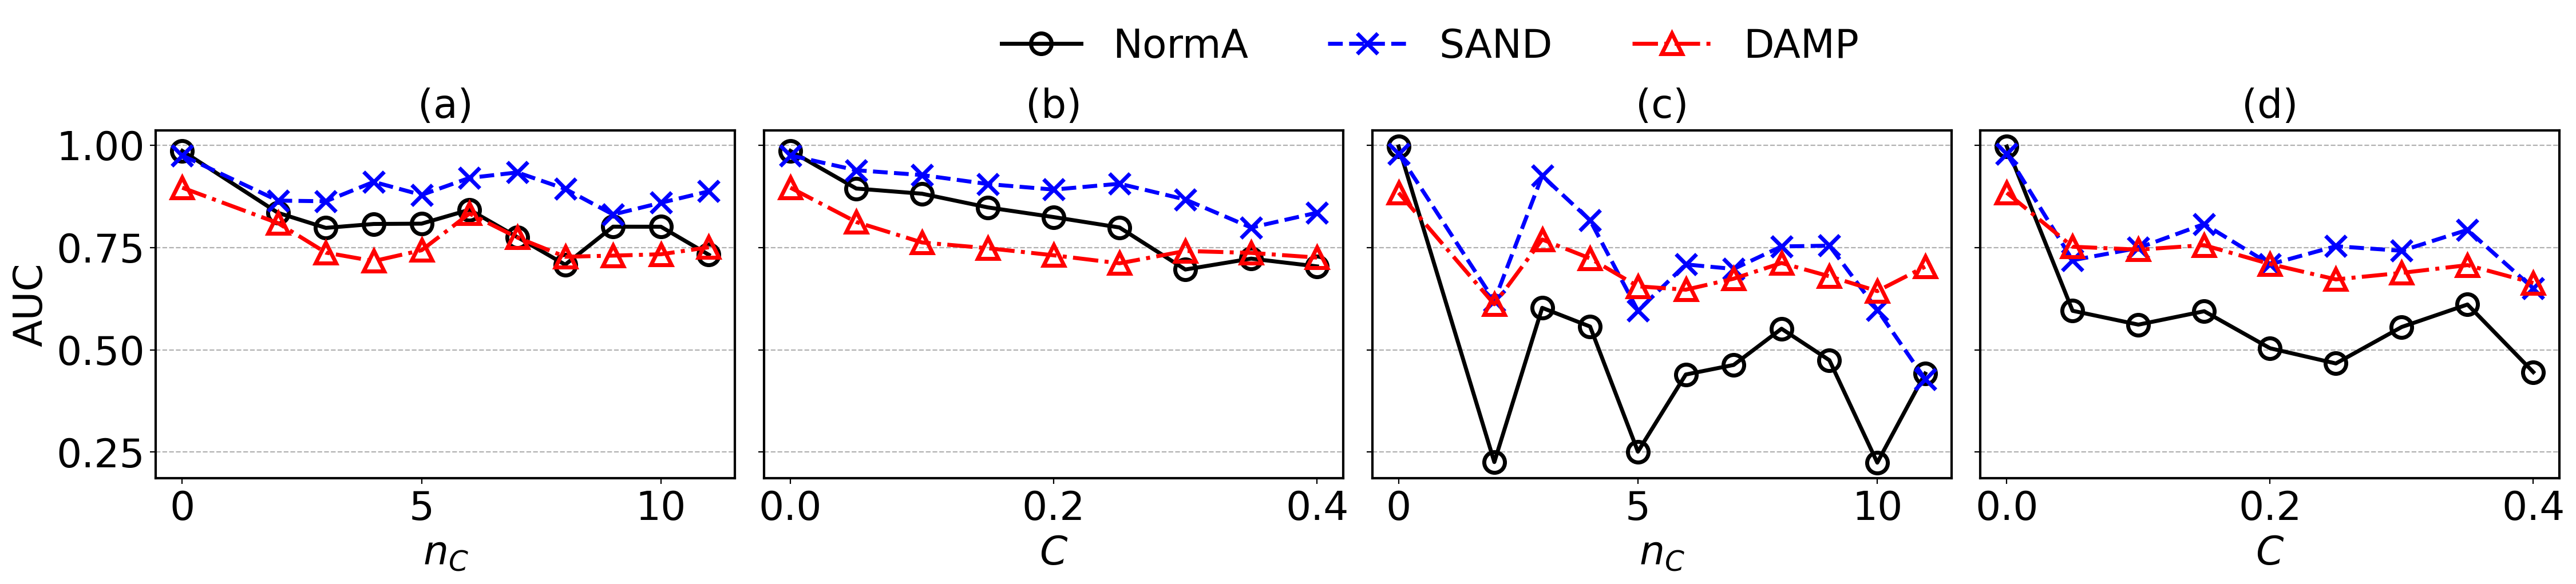

In [ ]:
result_org_r = pd.read_csv('./data/test_mod/org_803_805_real.csv', index_col=None)
result_n_drift_r = pd.read_csv('./data/test_mod/org_n_drift_real.csv', index_col=None)
result_p_drift_r = pd.read_csv('./data/test_mod/org_p_drift_real.csv', index_col=None)

result_org = pd.read_csv('./data/test_mod/figs/org_803.csv', index_col=None)
result_n_drift = pd.read_csv('./data/test_mod/figs/mod_n_drifts.csv', index_col=None)
result_p_drift = pd.read_csv('./data/test_mod/figs/mod_p_drifts.csv', index_col=None)

result_org_damp = pd.read_csv('./data/test/org/damp_real.csv', index_col=None)
result_n_drift_r_damp= pd.read_csv('./data/test/damp_real_n_drift.csv', index_col=None)
result_p_drift_r_damp= pd.read_csv('./data/test/damp_real_p_drift.csv', index_col=None)

result_org_damp_mod= pd.read_csv('./data/test_mod/org/damp_real.csv', index_col=None)
result_n_drift_mod_damp= pd.read_csv('./data/test_mod/damp_mod_n_drift.csv', index_col=None)
result_p_drift_mod_damp= pd.read_csv('./data/test_mod/damp_mod_p_drift.csv', index_col=None)

metric = 'AUC'
plt.rc('font', size=25)
plt.rc('axes', labelsize=25)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.linewidth'] = 1.5

methods = ['NormA', 'SAND', 'DAMP']
markers = ['o', 'x', '^']
lines = ['-', '--', '-.']
colors = ['black', 'blue', 'red']

x_n_d = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
x_p_d = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

result_p_drift_r_damp = result_p_drift_r_damp[result_p_drift_r_damp['p'] != 39]
result_p_drift_r_damp = result_p_drift_r_damp[result_p_drift_r_damp['p'] != 49]

result_p_drift_mod_damp = result_p_drift_mod_damp[result_p_drift_mod_damp['p'] != 39]
result_p_drift_mod_damp = result_p_drift_mod_damp[result_p_drift_mod_damp['p'] != 49]

fig, axes = plt.subplots(1, 4, figsize=(25,4), sharey=True)
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.96, top=0.88, wspace=0.05, hspace=0.1)
ax_nr = axes[0]
ax_pr = axes[1]
ax_n = axes[2]
ax_p = axes[3]

markersize = 13
linewidth= 2.5

for i, m in enumerate(methods):
    if m == 'DAMP':
        ax_nr.plot(x_n_d, [np.mean(result_org_damp.groupby('method').get_group(m)[metric])] + list(result_n_drift_r_damp.groupby('method').get_group(m).sort_values(by='n')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i], mfc='none', mec=colors[i], mew=linewidth, markersize=markersize, linewidth=linewidth, label=m)
        ax_pr.plot(x_p_d, [np.mean(result_org_damp.groupby('method').get_group(m)[metric])] + list(result_p_drift_r_damp.groupby('method').get_group(m).sort_values(by='p')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i], mfc='none', mec=colors[i], mew=linewidth, markersize=markersize, linewidth=linewidth,label=m)
        ax_n.plot(x_n_d, [np.mean(result_org_damp_mod.groupby('method').get_group(m)[metric])] + list(result_n_drift_mod_damp.groupby('method').get_group(m).sort_values(by='n')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none', mec=colors[i], mew=linewidth, markersize=markersize, linewidth=linewidth,label=m)
        ax_p.plot(x_p_d, [np.mean(result_org_damp_mod.groupby('method').get_group(m)[metric])] + list(result_p_drift_mod_damp.groupby('method').get_group(m).sort_values(by='p')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none', mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth,label=m)
    else:
        ax_nr.plot(x_n_d, [np.mean(result_org_r.groupby('method').get_group(m)[metric])] + list(result_n_drift_r.groupby('method').get_group(m).sort_values(by='n')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i], mfc='none', mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth,label=m)
        ax_pr.plot(x_p_d, [np.mean(result_org_r.groupby('method').get_group(m)[metric])] + list(result_p_drift_r.groupby('method').get_group(m).sort_values(by='p')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none', mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth,label=m)
        ax_n.plot(x_n_d, [np.mean(result_org.groupby('method').get_group(m)[metric])] + list(result_n_drift.groupby('method').get_group(m).sort_values(by='n')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none', mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth,label=m)
        ax_p.plot(x_p_d, [np.mean(result_org.groupby('method').get_group(m)[metric])] + list(result_p_drift.groupby('method').get_group(m).sort_values(by='p')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none',mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth, label=m)
# ax_nr.set_title(f"Drift injection using 3-existed data", x=1.1, y=1.03, fontsize=25)
# ax_pr.set_title(rf"$\mathbf{{o-modulation}}$", y=1.2, fontsize=20)
# ax_n.set_title(f"Drift injection using 3-different modulation", x=1.1,y=1.03, fontsize=25)
# ax_p.set_title(rf"$\mathbf{{o-modulation}}$", y=1.2, fontsize=20)

ax_nr.set_title('(a)', y=1.01, fontsize=25)
ax_pr.set_title('(b)', y=1.01, fontsize=25)
ax_n.set_title('(c)', y=1.01 , fontsize=25)
ax_p.set_title('(d)', y=1.01 , fontsize=25)

ax_nr.set_xlabel(r'$n_C$')
ax_n.set_xlabel(r'$n_C$')
ax_nr.set_ylabel(metric)

ax_pr.set_xlabel(r'$C$')
ax_p.set_xlabel(r'$C$')
ax_nr.legend(ncol=3, loc='upper center', frameon =False, fontsize=25, bbox_to_anchor=(2.2, 1.4))

for ax in axes.flat:
    # ax.set_ylim(y_min, y_max)
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=1)

plt.savefig('./png/comparison.png', bbox_inches='tight')

In [ ]:
pd.options.display.float_format = '{:.2f}'.format
# ecg_org =result_org_r.groupby('method').mean()
# ecg_org_damp =result_org_damp.groupby('method').mean()
# auc_n_drift_norma_r = result_n_drift_r.groupby('method').get_group('NormA').sort_values(by='n').set_index('n')
# auc_n_dirft_sand_r = result_n_drift_r.groupby('method').get_group('SAND').sort_values(by='n').set_index('n')
# auc_n_dirft_damp_r = result_n_drift_r_damp.groupby('method').get_group('DAMP').sort_values(by='n').set_index('n')

# ecg_org =result_org_r.groupby('method').mean()
# ecg_org_damp =result_org_damp.groupby('method').mean()
# auc_n_drift_norma_r = result_p_drift_r.groupby('method').get_group('NormA').sort_values(by='p').set_index('p')
# auc_n_dirft_sand_r = result_p_drift_r.groupby('method').get_group('SAND').sort_values(by='p').set_index('p')
# auc_n_dirft_damp_r = result_p_drift_r_damp.groupby('method').get_group('DAMP').sort_values(by='p').set_index('p')

ecg_org =result_org.groupby('method').mean()
ecg_org_damp =result_org_damp_mod.groupby('method').mean()
auc_n_drift_norma_r = result_n_drift.groupby('method').get_group('NormA').sort_values(by='n').set_index('n')
auc_n_dirft_sand_r = result_n_drift.groupby('method').get_group('SAND').sort_values(by='n').set_index('n')
auc_n_dirft_damp_r = result_n_drift_mod_damp.groupby('method').get_group('DAMP').sort_values(by='n').set_index('n')

# ecg_org =result_org.groupby('method').mean()
# ecg_org_damp =result_org_damp_mod.groupby('method').mean()
# auc_n_drift_norma_r = result_p_drift.groupby('method').get_group('NormA').sort_values(by='p').set_index('p')
# auc_n_dirft_sand_r = result_p_drift.groupby('method').get_group('SAND').sort_values(by='p').set_index('p')
# auc_n_dirft_damp_r = result_p_drift_mod_damp.groupby('method').get_group('DAMP').sort_values(by='p').set_index('p')

display((ecg_org['AUC'].loc['NormA'] - auc_n_drift_norma_r[['AUC']]) / ecg_org['AUC'].loc['NormA'])
display((ecg_org['AUC'].loc['SAND'] - auc_n_dirft_sand_r[['AUC']]) / ecg_org['AUC'].loc['SAND'])
display((ecg_org_damp['AUC'].loc['DAMP'] - auc_n_dirft_damp_r[['AUC']]) / ecg_org_damp['AUC'].loc['DAMP'])
display((auc_n_dirft_sand_r[['AUC']]-auc_n_drift_norma_r[['AUC']])/auc_n_drift_norma_r[['AUC']])

,AUC
n,
2,0.77
3,0.40
4,0.44
5,0.75
6,0.56
7,0.54
8,0.45
9,0.52
10,0.77


,AUC
n,
2,0.37
3,0.06
4,0.17
5,0.39
6,0.28
7,0.29
8,0.23
9,0.23
10,0.39


,AUC
n,
2,0.31
3,0.13
4,0.18
5,0.26
6,0.27
7,0.24
8,0.19
9,0.23
10,0.27


,AUC
n,
2,1.74
3,0.54
4,0.47
5,1.37
6,0.61
7,0.51
8,0.36
9,0.59
10,1.66


In [ ]:
print(((ecg_org['AUC'].loc['NormA'] - auc_n_drift_norma_r[['AUC']]) / ecg_org['AUC'].loc['NormA']).mean())
print(((ecg_org['AUC'].loc['SAND'] - auc_n_dirft_sand_r[['AUC']]) / ecg_org['AUC'].loc['SAND']).mean())
print(((ecg_org_damp['AUC'].loc['DAMP'] - auc_n_dirft_damp_r[['AUC']]) / ecg_org_damp['AUC'].loc['DAMP']).mean())

AUC   0.19
dtype: float64
AUC   0.09
dtype: float64
AUC   0.17
dtype: float64
